1. ANALYTICAL PROOF
H =
 [[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

Z =
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Step 1:  Z . H =
 [[ 0.7071+0.j  0.7071+0.j]
 [-0.7071+0.j  0.7071+0.j]]

Step 2:  H . (Z . H) =
 [[-0.+0.j  1.+0.j]
 [ 1.+0.j -0.+0.j]]

Target  X =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Absolute Numerical Difference: 2.22044605e-16
STATUS: SUCCESS - H.Z.H is exactly the X matrix.

Hand calculation, column by column:
  H|0> = |+> ,  Z|+> = |-> ,  H|-> = |1>   =>  HZH|0> = |1>
  H|1> = |-> ,  Z|-> = |+> ,  H|+> = |0>   =>  HZH|1> = |0>
  Swapping |0> and |1> is precisely what the X gate does.

2. CIRCUIT UNITARY COMPARISON (Qiskit)
Unitary of the H-Z-H circuit:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Unitary of the X circuit:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Operator.equiv() says the two circuits are equivalent: True

3. STATEVECTOR SIMULATION ON DIFFERENT INPUTS
  input |0>     -> HZH: [0.+0.j 1.+0.j]   X: [0.+0.j 1.+0.j]   identical: True
  input |1>     -> HZH:

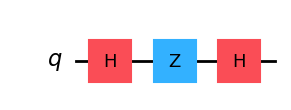

--- Equivalent X Circuit ---


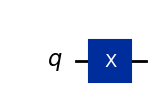


BONUS: the same trick works the other way round - H.X.H = Z.
Conjugating by H swaps the X and Z axes of the Bloch sphere.


In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, random_statevector
from qiskit_aer import AerSimulator

# ==============================================================
# WEEK 3 - CHALLENGE
# Prove gate equivalence:  H . Z . H  ==  X
# (1) analytically, by multiplying the matrices
# (2) by comparing the circuit unitaries in Qiskit
# (3) by simulating both circuits on several input states
# ==============================================================

H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)

# ==================================================================
# 1. ANALYTICAL PROOF
# ==================================================================
print("=" * 62)
print("1. ANALYTICAL PROOF")
print("=" * 62)
print("H =\n", np.round(H, 4))
print("\nZ =\n", np.round(Z, 4))

ZH = Z @ H
print("\nStep 1:  Z . H =\n", np.round(ZH, 4))

HZH = H @ ZH
print("\nStep 2:  H . (Z . H) =\n", np.round(HZH, 4))

print("\nTarget  X =\n", np.round(X, 4))

diff = np.max(np.abs(HZH - X))
print(f"\nAbsolute Numerical Difference: {diff:.8e}")
print("STATUS: SUCCESS - H.Z.H is exactly the X matrix."
      if np.isclose(diff, 0.0, atol=1e-12) else "STATUS: FAILED")

print("\nHand calculation, column by column:")
print("  H|0> = |+> ,  Z|+> = |-> ,  H|-> = |1>   =>  HZH|0> = |1>")
print("  H|1> = |-> ,  Z|-> = |+> ,  H|+> = |0>   =>  HZH|1> = |0>")
print("  Swapping |0> and |1> is precisely what the X gate does.")

# ==================================================================
# 2. CIRCUIT-LEVEL UNITARY COMPARISON
# ==================================================================
print("\n" + "=" * 62)
print("2. CIRCUIT UNITARY COMPARISON (Qiskit)")
print("=" * 62)

qc_hzh = QuantumCircuit(1)
qc_hzh.h(0)
qc_hzh.z(0)
qc_hzh.h(0)

qc_x = QuantumCircuit(1)
qc_x.x(0)

U_hzh = Operator(qc_hzh)
U_x = Operator(qc_x)

print("Unitary of the H-Z-H circuit:")
print(np.round(U_hzh.data, 4))
print("\nUnitary of the X circuit:")
print(np.round(U_x.data, 4))
print(f"\nOperator.equiv() says the two circuits are equivalent: "
      f"{U_hzh.equiv(U_x)}")

# ==================================================================
# 3. SIMULATION ON SEVERAL INPUT STATES
# ==================================================================
print("\n" + "=" * 62)
print("3. STATEVECTOR SIMULATION ON DIFFERENT INPUTS")
print("=" * 62)

test_inputs = {
    "|0>": Statevector([1, 0]),
    "|1>": Statevector([0, 1]),
    "|+>": Statevector([1 / np.sqrt(2), 1 / np.sqrt(2)]),
    "|->": Statevector([1 / np.sqrt(2), -1 / np.sqrt(2)]),
    "random": random_statevector(2, seed=35),
}

all_match = True
for label, psi in test_inputs.items():
    out_hzh = psi.evolve(qc_hzh)
    out_x = psi.evolve(qc_x)
    match = np.allclose(out_hzh.data, out_x.data)
    all_match &= match
    print(f"  input {label:7s} -> HZH: {np.round(out_hzh.data, 4)}"
          f"   X: {np.round(out_x.data, 4)}   identical: {match}")

print("\nSTATUS: SUCCESS - both circuits produce identical output states."
      if all_match else "\nSTATUS: FAILED")

# ==================================================================
# 4. SHOT-BASED CONFIRMATION
# ==================================================================
SHOTS = 4096
sim = AerSimulator()
print("\n" + "=" * 62)
print(f"4. MEASUREMENT COUNTS ({SHOTS} shots each)")
print("=" * 62)

for label, prep in [("|0>", None), ("|1>", "x")]:
    for name, body in [("H-Z-H", qc_hzh), ("X", qc_x)]:
        circ = QuantumCircuit(1)
        if prep == "x":
            circ.x(0)                      # prepare |1>
        circ.compose(body, inplace=True)
        circ.measure_all()
        counts = sim.run(circ, shots=SHOTS).result().get_counts()
        print(f"  input {label} through {name:6s}: {counts}")

print("\nBoth gates send |0> -> |1> and |1> -> |0> in every single shot.")

# ==================================================================
# 5. CIRCUIT DIAGRAMS
# ==================================================================
print("\n--- H-Z-H Circuit ---")
display(qc_hzh.draw(output="mpl", style="iqp"))
print("--- Equivalent X Circuit ---")
display(qc_x.draw(output="mpl", style="iqp"))

print("\nBONUS: the same trick works the other way round - H.X.H = Z.")
print("Conjugating by H swaps the X and Z axes of the Bloch sphere.")